<a href="https://colab.research.google.com/github/MaysNassar/Stroke-Prediction-ML-Model-Comparison/blob/main/LogReg%2C_Random_Forest%2C_KNN_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LogReg, Random Forest, KNN (Core)

- Mays Nassar
-----------

# Import packages and libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn import set_config
set_config(transform_output='pandas')

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  # print header and report
  header = '-'*60
  print(header,f'Classification Metrics: {label}', header, sep='\n')
  print(report)

  ## Confusion Metrics Subplots
  fig, axes =plt.subplots(ncols=2, figsize=figsize)

  # Create confusion matrix of raw matrix
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None,
                                         cmap='gist_gray', colorbar=colorbar,
                                         ax=axes[0]);
  axes[0].set_title('Raw Counts')

  # Create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize,
                                          cmap=cmap, colorbar=colorbar,
                                          ax=axes[1]);
  axes[1].set_title('Normalized Confusion Matrix')

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred,
                                        output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):

  # Get prediction for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metric s for training data
  results_train = classification_metrics(y_train, y_train_pred, # verbose = verbose,
                                         output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                         label= 'Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose=verbose,
                                        output_dict=True, figsize=figsize,
                                        colorbar=colorbar, cmap=cmap_test,
                                        label = 'Test Data')
  if output_dict == True:
    # Store results in a dataframe if output_frame is True
    results_dict = {'train': results_train,
                    'test': results_test}
    return results_dict

In [3]:
def plot_cv_results(gs, param_name='param_logisticregression__C',logx=True):
  # Making a data frame with cv_results
  cv_results = pd.DataFrame(gs.cv_results_)
  # Save the train/test scores +value for C
  scores = cv_results[[param_name, 'mean_train_score', 'mean_test_score']]
  scores = scores.set_index(param_name)

  ## Plot the training vs test scores vs. C
  ax = scores.plot(y=['mean_test_score', 'mean_train_score'],
                 style='o-', logx= logx)
  ax.set(ylabel=gs.scoring)
  print(scores['mean_test_score'])
  return ax

# Load Data

In [4]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week07/stroke.csv'
df= pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [6]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,52


In [7]:
# Check for stroke imbalance
df['stroke'].value_counts(normalize=True)

,proportion
stroke,
0,0.879507
1,0.120493


# Make Model pipeline and Fit on Trainig Data

In [8]:
# Define X and y
X = df.drop(columns=['id','stroke'])
y = df['stroke']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

## Categorical Preprocessing Pipeline

In [9]:
# Categorical Preprocessing Pipeline
# Save list of column names
ohe_cols= X_train.select_dtypes('object').columns
print('OneHotEncoder Columns', ohe_cols)

# instantiate the individual preprocessors
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Make a pipeline with imputer and encoder
ohe_pipe = make_pipeline( ohe_encoder)

# Making a ohe_tuple for ColumnTransformer
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


## Numerical Preprocessing Pipeline

In [10]:
# Numerical Preprocessing Pipeline
# Save list of column names
num_cols= X_train.select_dtypes('number').columns
print('Numeric Columns', num_cols)

# instantiate the individual preprocessors
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()

# Make a pipeline with imputer and scler
num_pipe = make_pipeline(impute_median, scaler)

# Making a num_tuple for ColumnTransformer
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')


In [11]:
# Create a columntransformer
preprocessor = ColumnTransformer([num_tuple, ohe_tuple],
                                 verbose_feature_names_out=False)

# Logistic Regression

In [12]:
# Istantiate a deafult  logreg
logreg = LogisticRegression()

# Make a pipeline
logreg_pipe = make_pipeline(preprocessor, logreg)

# Fit the pipeline
logreg_pipe.fit(X_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression())])

## Evaluate the model

------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       749
           1       0.64      0.16      0.25       103

    accuracy                           0.89       852
   macro avg       0.77      0.57      0.59       852
weighted avg       0.86      0.89      0.86       852



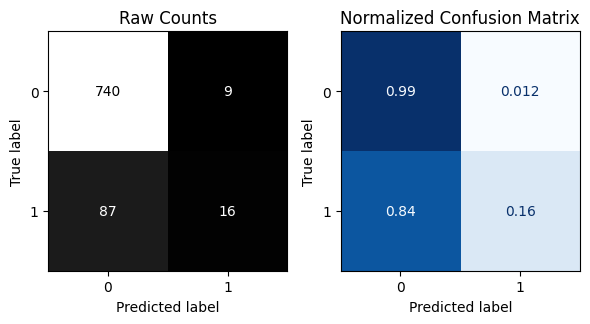


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       251
           1       0.33      0.06      0.10        34

    accuracy                           0.87       285
   macro avg       0.61      0.52      0.52       285
weighted avg       0.82      0.87      0.83       285



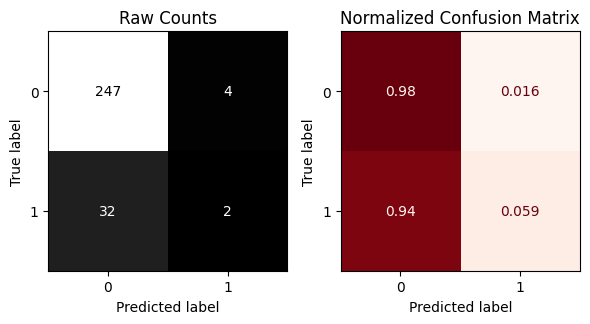

In [13]:
logreg_results = evaluate_classification(logreg_pipe, X_train, y_train, X_test, y_test)

# Tuning Parameters

In [14]:
# obtain params
logreg_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                   ('categorical',
                                    Pipeline(steps=[('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
          'smoking_status'],
         dtype='object'))],
        

In [15]:
from sklearn.model_selection import ParameterGrid

logreg_pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))

# Only valid combinations
params = [
    # L1 regularization
    {'logisticregression__penalty': ['l1'],
     'logisticregression__solver': ['liblinear'],
     'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
     'logisticregression__class_weight': [None, 'balanced']},

    # L2 regularization
    {'logisticregression__penalty': ['l2'],
     'logisticregression__solver': ['lbfgs', 'liblinear', 'saga'],
     'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
     'logisticregression__class_weight': [None, 'balanced']},

    # ElasticNet (only with saga)
    {'logisticregression__penalty': ['elasticnet'],
     'logisticregression__solver': ['saga'],
     'logisticregression__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
     'logisticregression__C': [0.01, 0.1, 1, 10],
     'logisticregression__class_weight': [None, 'balanced']},
]

gs_logreg = GridSearchCV(logreg_pipe, params, verbose=True, n_jobs=-1,
                         cv=3, return_train_score=True, scoring='recall_macro')

In [ ]:

gs_logreg.fit(X_train, y_train)

Fitting 3 folds for each of 88 candidates, totalling 264 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotE...
                          'logisticregression__solver': ['lbfgs', 'liblinear',
                                                         'saga']},
                         {'logisticregression__C': [0.01, 0.1, 1, 10],
                          'logisticregression__class_weight': [None,
                                                               'balanced'],
                          'logisticregression__l1_ratio': [0.1, 0.3, 0.5, 0.7,
                                                           0.9],
                          'logisticregression__penalty': ['elasticnet'],
                          'logisticregression__solver': ['saga']}],
             return_train_score=True, scoring='recall_macro', verbose=True)

In [ ]:
print("Best params:", gs_logreg.best_params_)
print("Best CV score (recall_macro):", gs_logreg.best_score_)
print("\nTop 5 models:")
results_df = pd.DataFrame(gs_logreg.cv_results_).sort_values('rank_test_score')
results_df.head()

Best params: {'logisticregression__C': 1, 'logisticregression__class_weight': 'balanced', 'logisticregression__l1_ratio': 0.7, 'logisticregression__penalty': 'elasticnet', 'logisticregression__solver': 'saga'}
Best CV score (recall_macro): 0.7316980639645415

Top 5 models:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__class_weight,param_logisticregression__penalty,param_logisticregression__solver,param_logisticregression__l1_ratio,params,...,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
76,0.733092,0.014973,0.019842,0.000291,1.0,balanced,elasticnet,saga,0.7,"{'logisticregression__C': 1, 'logisticregressi...",...,0.702118,0.756741,0.731698,0.022530,1,0.816314,0.840362,0.802412,0.819696,0.015677
75,0.669016,0.122282,0.019939,0.000157,1.0,balanced,elasticnet,saga,0.5,"{'logisticregression__C': 1, 'logisticregressi...",...,0.702118,0.754733,0.731695,0.021972,2,0.811304,0.840362,0.801412,0.817692,0.016531
74,0.728885,0.100510,0.039277,0.011699,1.0,balanced,elasticnet,saga,0.3,"{'logisticregression__C': 1, 'logisticregressi...",...,0.696118,0.740448,0.723600,0.019598,3,0.811304,0.846606,0.810118,0.822676,0.016928
77,1.084022,0.028982,0.027492,0.010723,1.0,balanced,elasticnet,saga,0.9,"{'logisticregression__C': 1, 'logisticregressi...",...,0.683412,0.744464,0.721370,0.027050,4,0.808065,0.837356,0.798059,0.814493,0.016674
35,0.387728,0.026244,0.022620,0.000919,1.0,balanced,l2,saga,NaN,"{'logisticregression__C': 1, 'logisticregressi...",...,0.690118,0.760987,0.720878,0.029678,5,0.816546,0.838358,0.812471,0.822458,0.011365


------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       749
           1       0.33      0.82      0.47       103

    accuracy                           0.78       852
   macro avg       0.65      0.79      0.67       852
weighted avg       0.89      0.78      0.81       852



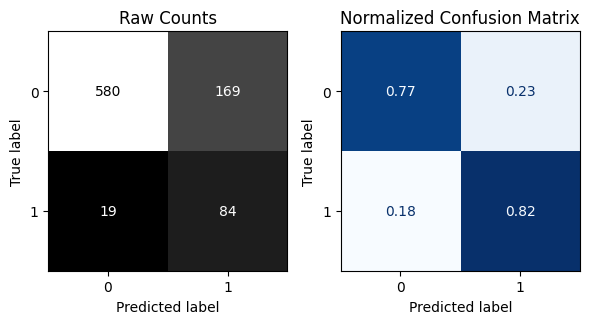


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       251
           1       0.23      0.56      0.33        34

    accuracy                           0.73       285
   macro avg       0.58      0.66      0.58       285
weighted avg       0.84      0.73      0.77       285



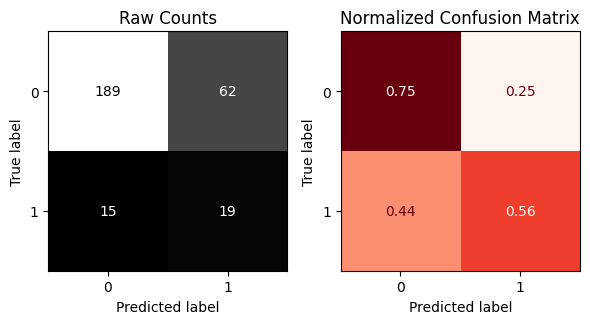

In [ ]:
logreg_tuned = evaluate_classification(gs_logreg.best_estimator_, X_train, y_train, X_test, y_test)

> ###  Which combination of hyperparameters led to the best-tuned model?
  - Best params: {'logisticregression__C': 1, 'logisticregression__class_weight': 'balanced', 'logisticregression__l1_ratio': 0.7, 'logisticregression__penalty': 'elasticnet', 'logisticregression__solver': 'saga'}

    - Best CV score (recall_macro): 0.7316980639645415





# K-NearestNeighbors (KNN)

In [16]:
# MAke a Default KNN
knn_pipe = make_pipeline(preprocessor, KNeighborsClassifier())

# Fit the pipeline
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('kneighborsclassifier', KNeighborsClassifier())])

## Evaluate the model

------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       749
           1       0.64      0.20      0.31       103

    accuracy                           0.89       852
   macro avg       0.77      0.59      0.62       852
weighted avg       0.87      0.89      0.86       852



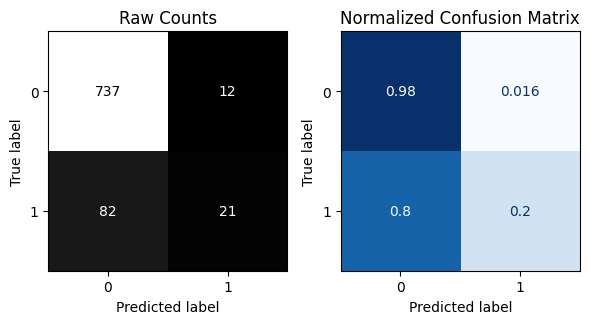


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.17      0.03      0.05        34

    accuracy                           0.87       285
   macro avg       0.52      0.50      0.49       285
weighted avg       0.80      0.87      0.82       285



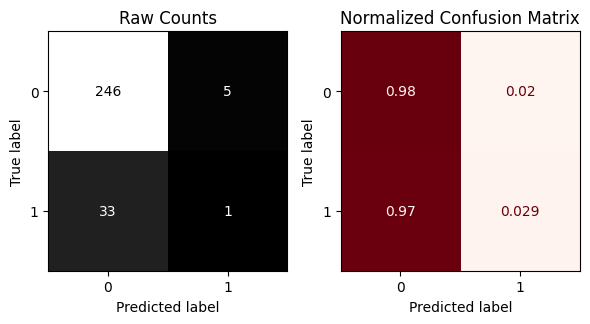

In [17]:
knn_results = evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

## Tuning Parameter

In [18]:
# MAking every other value from the range odd values
nneighbors_list = list(range(1,21,2))
nneighbors_list

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

In [19]:
# Get list of params for knn model pipeline
knn_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                   ('categorical',
                                    Pipeline(steps=[('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
          'smoking_status'],
         dtype='object'))],
        

In [20]:

params = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 15, 21],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan'],
}

In [ ]:
# Istantiate GridSearchCV
gs_knn = GridSearchCV(knn_pipe, params, verbose=True, n_jobs=-1,
                      cv=3, return_train_score=True, scoring='recall_macro')
# Fit gs on training data
gs_knn.fit(X_train, y_train)
# obtain best param value for k
gs_knn.best_params_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


{'kneighborsclassifier__metric': 'euclidean',
 'kneighborsclassifier__n_neighbors': 9,
 'kneighborsclassifier__weights': 'uniform'}

In [ ]:
# increasing max_columns to see full cv_results
pd.set_option('display.max_columns',50)
# Getting the cv_results as a dataframe
cv_knn_results = pd.DataFrame(gs_knn.cv_results_)
cv_knn_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kneighborsclassifier__metric,param_kneighborsclassifier__n_neighbors,param_kneighborsclassifier__weights,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,0.046226,0.015296,0.038415,0.014687,euclidean,3,uniform,"{'kneighborsclassifier__metric': 'euclidean', ...",0.536824,0.520118,0.553356,0.536766,0.013570,10,0.678153,0.660887,0.621000,0.653347,0.023934
1,0.043901,0.016215,0.038706,0.013134,euclidean,3,distance,"{'kneighborsclassifier__metric': 'euclidean', ...",0.538824,0.518118,0.551348,0.536096,0.013703,11,1.000000,1.000000,1.000000,1.000000,0.000000
2,0.074020,0.041041,0.083251,0.007803,euclidean,5,uniform,"{'kneighborsclassifier__metric': 'euclidean', ...",0.563529,0.522118,0.571658,0.552435,0.021693,5,0.599445,0.640920,0.611647,0.617337,0.017403
3,0.101201,0.025997,0.081175,0.019435,euclidean,5,distance,"{'kneighborsclassifier__metric': 'euclidean', ...",0.563529,0.518118,0.569650,0.550432,0.022986,6,1.000000,1.000000,1.000000,1.000000,0.000000
4,0.155629,0.013845,0.147011,0.010140,euclidean,7,uniform,"{'kneighborsclassifier__metric': 'euclidean', ...",0.574235,0.498706,0.569650,0.547530,0.034575,7,0.586187,0.609930,0.568529,0.588215,0.016962


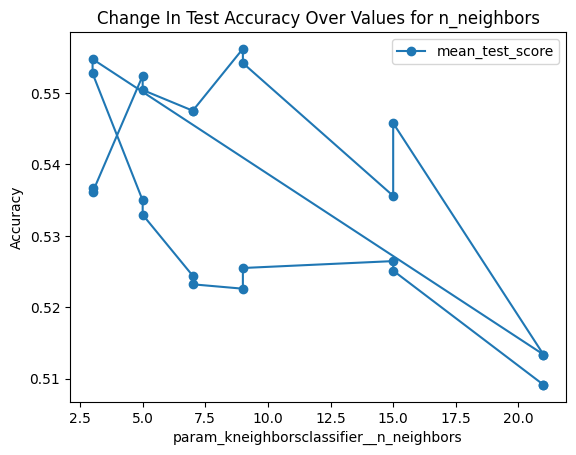

In [ ]:
# Plot accuracy with various values for K
ax = cv_knn_results.plot(x='param_kneighborsclassifier__n_neighbors',
                     y='mean_test_score', style='-o')
ax.set(ylabel='Accuracy', title='Change In Test Accuracy Over Values for n_neighbors');
print()

## Evaluate the model

------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       749
           1       0.64      0.14      0.22       103

    accuracy                           0.89       852
   macro avg       0.76      0.56      0.58       852
weighted avg       0.86      0.89      0.85       852



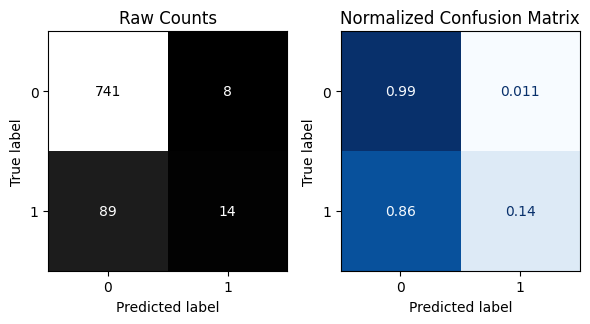


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       251
           1       0.00      0.00      0.00        34

    accuracy                           0.87       285
   macro avg       0.44      0.49      0.47       285
weighted avg       0.77      0.87      0.82       285



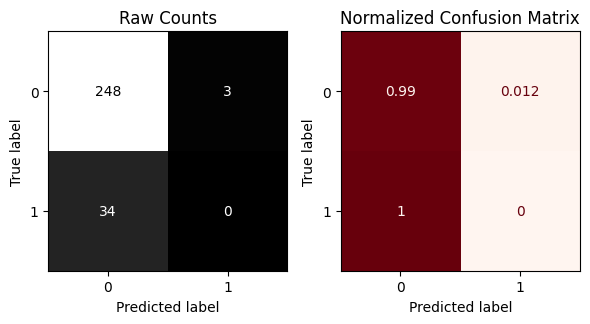

In [ ]:
# Obtain complete evaluation for best performing model (k=9)
evaluate_classification(gs_knn.best_estimator_, X_train, y_train, X_test, y_test)

> ###  Which combination of hyperparameters led to the best-tuned model?
  - {'kneighborsclassifier__metric': 'euclidean',
 'kneighborsclassifier__n_neighbors': 9,
 'kneighborsclassifier__weights': 'uniform'}



# Random Forest

In [28]:
# Make  deafult random forest pipe
rf = RandomForestClassifier()
rf_pipe = make_pipeline(preprocessor, RandomForestClassifier())

# Fit the pipeline
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier', RandomForestClassifier())])

In [31]:
def plot_importance(importances, top_n=None, figsize=(8,6)):
  # Sorting with asc=False for correct order of bars
  if top_n==None:
    ## Sort all features as se title
    plot_vals = importances.sort_values()
    title = 'All Features - Ranked By Importance'
  else:
    ## Sort features and keep top_n and set title
    plot_vals = importances.sort_values().tail(top_n)
    title = f'Top {top_n} Most Important Features'
  ## Plottng top n importances
  ax= plot_vals.plot(kind='barh', figsize=figsize)
  ax.set(xlabel='Importance',
         ylabel='Feature Names',
         title=title)
  ## Return ax in case want to continue to update/modify figure
  return ax

In [30]:
# Get feature importance
# The rf_pipe has already been fitted in the previous cell.
fitted_rf_model = rf_pipe.named_steps['randomforestclassifier']
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(fitted_rf_model.feature_importances_, index = feature_names,
                        name='Feature Importance')

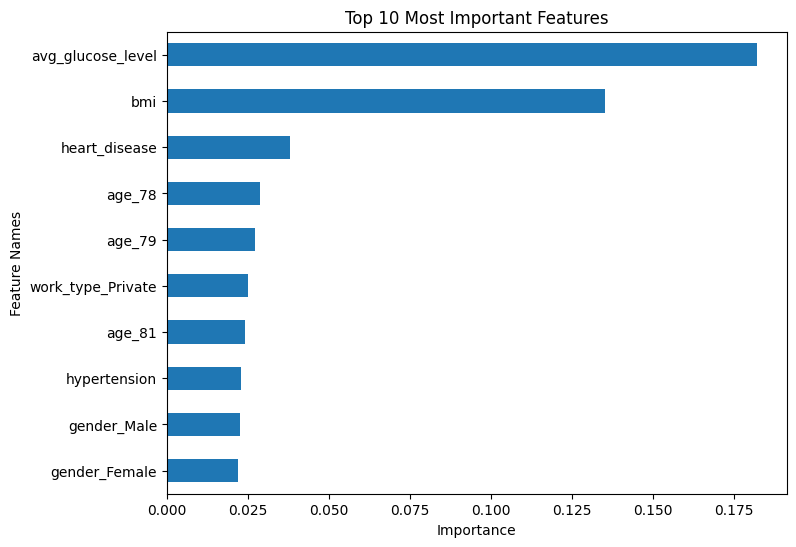

In [33]:
plot_importance(importances, top_n=10);


## Evaluate the model

------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



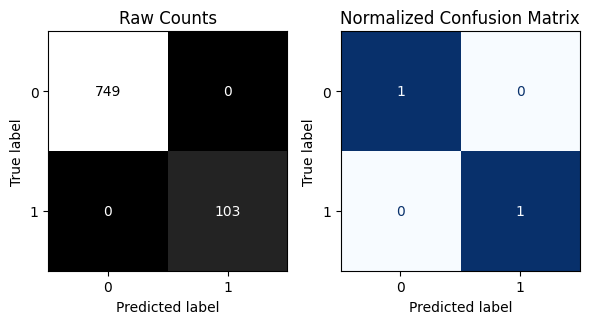


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.00      0.00      0.00        34

    accuracy                           0.86       285
   macro avg       0.44      0.49      0.46       285
weighted avg       0.77      0.86      0.82       285



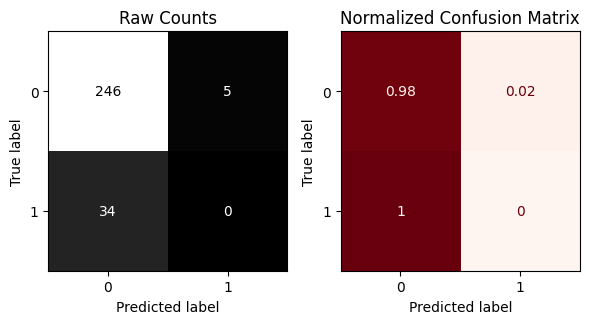

In [ ]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

## Tuning Parameter

In [ ]:
# get params
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                   ('categorical',
                                    Pipeline(steps=[('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
          'smoking_status'],
         dtype='object'))],
        

In [ ]:
params = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [10, 15, 20, None],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    'randomforestclassifier__class_weight': ['balanced', None]}

In [ ]:
gs_rf = GridSearchCV(rf_pipe, params, verbose=True, n_jobs=-1,
                     cv=3, return_train_score=True, scoring='recall_macro')
gs_rf.fit(X_train, y_train)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotE...
             param_grid={'randomforestclassifier__class_weight': ['balanced',
                                                                  None],
                         'randomforestclassifier__max_depth': [10, 15, 20,
                                                               None],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [50, 100,
                                                                  200]},
             return_train_score=True, scoring='recall_macro', verbose=True)

In [ ]:
# obtain best param
gs_rf.best_params_

{'randomforestclassifier__class_weight': 'balanced',
 'randomforestclassifier__max_depth': 10,
 'randomforestclassifier__max_features': 'log2',
 'randomforestclassifier__min_samples_leaf': 4,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__n_estimators': 100}

## Evaluate the model

------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.80      0.88       749
           1       0.37      0.83      0.51       103

    accuracy                           0.81       852
   macro avg       0.67      0.81      0.69       852
weighted avg       0.90      0.81      0.83       852



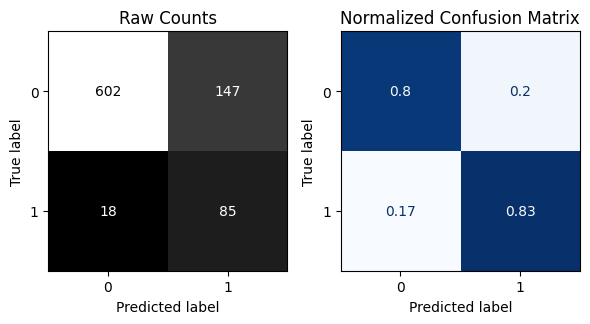


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       251
           1       0.24      0.50      0.33        34

    accuracy                           0.75       285
   macro avg       0.58      0.64      0.59       285
weighted avg       0.84      0.75      0.79       285



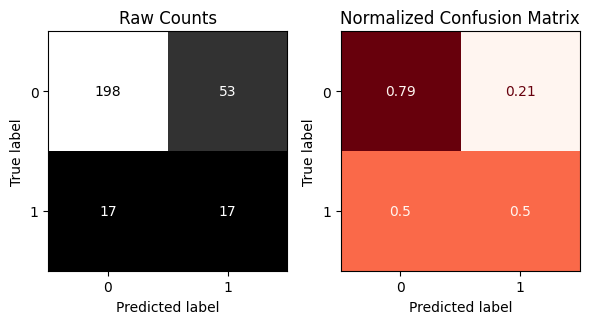

In [ ]:
evaluate_classification(gs_rf.best_estimator_, X_train, y_train, X_test, y_test)

> ###  Which combination of hyperparameters led to the best-tuned model?
  - {'randomforestclassifier__class_weight': 'balanced',
 'randomforestclassifier__max_depth': 10,
 'randomforestclassifier__max_features': 'log2',
 'randomforestclassifier__min_samples_leaf': 4,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__n_estimators': 100}



In [ ]:
results = pd.DataFrame({
    'Model': ['LogReg', 'KNN', 'RF'],
    'Best CV Recall': [gs_logreg.best_score_, gs_knn.best_score_, gs_rf.best_score_],
    'Best Params': [gs_logreg.best_params_, gs_knn.best_params_, gs_rf.best_params_]
})

for name, model in [('LogReg', gs_logreg), ('KNN', gs_knn), ('RF', gs_rf)]:
    y_pred = model.predict(X_test)
    print(f"{name} - Recall: {recall_score(y_test, y_pred, average='macro')}")


LogReg - Recall: 0.6559057886102648
KNN - Recall: 0.4940239043824701
RF - Recall: 0.6444223107569721


In [ ]:
  for name, model in [('LogReg', gs_logreg), ('KNN', gs_knn), ('RF', gs_rf)]:
       y_pred = model.predict(X_test)
       print(f"\n{name}")
       print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))
       print(f"Recall on Stroke: {recall_score(y_test, y_pred, pos_label=1)}")


LogReg
              precision    recall  f1-score   support

   No Stroke       0.93      0.75      0.83       251
      Stroke       0.23      0.56      0.33        34

    accuracy                           0.73       285
   macro avg       0.58      0.66      0.58       285
weighted avg       0.84      0.73      0.77       285

Recall on Stroke: 0.5588235294117647

KNN
              precision    recall  f1-score   support

   No Stroke       0.88      0.99      0.93       251
      Stroke       0.00      0.00      0.00        34

    accuracy                           0.87       285
   macro avg       0.44      0.49      0.47       285
weighted avg       0.77      0.87      0.82       285

Recall on Stroke: 0.0

RF
              precision    recall  f1-score   support

   No Stroke       0.92      0.79      0.85       251
      Stroke       0.24      0.50      0.33        34

    accuracy                           0.75       285
   macro avg       0.58      0.64      0.59       28

In [ ]:
from sklearn.metrics import precision_score, f1_score

for name, model in [('LogReg', gs_logreg), ('KNN', gs_knn), ('RF', gs_rf)]:
    y_pred = model.predict(X_test)
    prec = precision_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    print(f"{name}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

LogReg: Precision=0.235, Recall=0.559, F1=0.330
KNN: Precision=0.000, Recall=0.000, F1=0.000
RF: Precision=0.243, Recall=0.500, F1=0.327


- LogReg is fast, interpretable, lightweight — good for real-time prediction
- RF is slower, black-box, heavier — but potentially more accurate
- KNN is slow at prediction time (has to compute distances to all training samples) — bad for production